In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import SSG_mps
from PPO_SIL_pfolio_mps_trunk import MarketConfig, PPOSILConfig, train_ppo_sil, evaluate_policy, evaluate_and_plot_single_path, load_ppo_sil

In [3]:
DEVICE = 'mps'

In [4]:
log_returns_corr_matrix = pd.read_excel('/Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Calibration/SMI/FFTResults/CalibrationResults/corr_matrix.xlsx')
log_returns_corr_matrix = log_returns_corr_matrix.to_numpy(dtype=float)

FFT_estimates = pd.read_excel('/Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Calibration/SMI/FFTResults/CalibrationResults/FFT_estimates.xlsx')

portfolio_weights_df = pd.read_excel('/Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Calibration/SMI/FFTResults/CalibrationResults/pfolio_weights.xlsx')
portfolio_weights_df = portfolio_weights_df[portfolio_weights_df['TKR']!='Cash']
portfolio_weights_df['w'] = portfolio_weights_df['w']/100

df = pd.merge(FFT_estimates, portfolio_weights_df, on='TKR', how='outer')
df

,TKR,S0,r,mu,mu_uncapped,mu_Q,C,G,M,sigma,theta,nu,w
0,ABB,82.86,-0.0004,0.127094,0.184898,-0.012319,12.028845,12.968054,21.431640,0.294213,-0.366309,0.083134,0.0758
1,ALCC,49.61,-0.0004,-0.083546,-0.083546,-0.006060,11.271924,14.032037,21.542191,0.273092,-0.280050,0.088716,0.0222
2,CFR,156.55,-0.0004,0.000324,0.080265,-0.021527,106.265383,48.271206,48.273558,0.302004,-0.000107,0.009410,0.0552
3,GALD,158.35,-0.0004,0.187403,0.246114,-0.004830,27.445113,17.934348,40.144548,0.276116,-0.846653,0.036436,0.0181
4,GEBN,503.40,-0.0004,-0.006973,-0.006973,-0.026565,88.253821,58.969168,65.840212,0.213218,-0.156185,0.011331,0.0132
5,GIVN,2683.00,-0.0004,-0.058919,-0.058919,-0.028390,2.618908,5.165600,15.376532,0.256794,-0.336672,0.381838,0.0188
6,HOLN,76.26,-0.0004,0.133587,0.195023,-0.046450,20.039086,20.850715,30.237841,0.252126,-0.298359,0.049902,0.0247
7,LONN,474.20,-0.0004,0.011345,0.011345,-0.013668,17.456671,17.845342,25.153005,0.278893,-0.284201,0.057285,0.0261
8,NESN,76.88,-0.0004,-0.034524,-0.034524,-0.042247,12.186183,19.116281,37.332470,0.184801,-0.311054,0.082060,0.1505
9,NOVN,116.80,-0.0004,0.061636,0.078652,-0.034462,54.732930,45.214604,57.048538,0.206005,-0.251105,0.018271,0.1712


In [5]:
d = len(df)
T = 1.0
n_steps = int(3 * 252)
r = 0.0

mu = df['mu'].astype(float).to_list()
s0 = df['S0'].astype(float).to_list()

# New preferred SSG inputs.
sigma = df['sigma'].astype(float).to_list()
theta = df['theta'].astype(float).to_list()
nu = df['nu'].astype(float).to_list()

pfolio_value = 50000
risky_portfolio_value = float(df['w'].sum())*pfolio_value
cash = pfolio_value - risky_portfolio_value

value_per_asset = risky_portfolio_value * df['w'].to_numpy(dtype=float)
h0 = (value_per_asset/np.asarray(s0, dtype=float)).tolist()

print(f'Initial cash: {cash}')
print(f'Initial holdings: {h0}')

Initial cash: 69.99999999999272
Initial holdings: [45.675766352884395, 22.343196936101595, 17.605467901628874, 5.707186611935587, 1.3092491060786655, 0.3498635855385762, 16.171924993443486, 2.7481505693800083, 97.74278095733612, 73.1850684931507, 0.7854538252602988, 26.197646875000004, 0.9499955752212391, 14.589935064935064, 6.2500944733112895, 5.278162468960626, 1.078955348615091, 12.539974884889075, 98.15063500828273, 5.6315364120781535]


In [6]:
N_eff_min = 5
max_name_weight = 1.0/N_eff_min

s0_np = df["S0"].to_numpy(dtype=float)

min_holding = [0.0] * d
max_holding = [100.0] * d #(max_name_weight*pfolio_value/s0_np).tolist()
max_trade_size = [50.0] * d

print(max_holding)

[100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0]


In [7]:
market = MarketConfig(
    d=d,
    T=1.0,
    n_steps=int(252),
    r=r,

    mu=mu,
    s0=s0,
    h0=h0,
    cash0=cash,

    sigma=sigma,
    theta=theta,
    nu=nu,
    log_returns_corr_matrix=log_returns_corr_matrix,

    # SSG settings
    ssg_path_mean_samples=20,
    ssg_max_simulated_paths_per_chunk=8192,

    # Transaction costs
    fixed_cost=3.0,
    proportional_cost=1e-4,

    # Holding and trade constraints in shares
    min_holding=min_holding,
    max_holding=max_holding,
    max_trade_size=max_trade_size,

    allow_negative_cash=False,
    self_financing=True,

    # Initial-state randomisation
    randomize_initial_prices=False,
    randomize_initial_holdings=False,
    randomize_initial_cash=False,

    # Numerical conditioning only
    reward_scale=1.0e-3,
)

In [8]:
cfg = PPOSILConfig(
    seed=42,
    device=DEVICE,
    dtype="float32",

    train_iters=100,
    rollout_envs=512,

    gamma_rl=1.0,
    gae_lambda=0.97,

    ppo_epochs=3,
    minibatch_size=512,
    lr=2.0e-4,
    weight_decay=0.0,
    clip_eps=0.30,
    value_coef=0.50,
    entropy_coef=5e-2,
    target_kl=0.05,
    max_grad_norm=1.0,

    # Shared trunk
    hidden_dims=(512, 256, 128, 256, 512),
    activation="tanh",
    layer_norm=False,
    decision_bias=0.0,
    init_log_std=0.0,
    min_log_std=-3.0,
    max_log_std=1.0,

    # SIL
    use_sil=True,
    sil_buffer_capacity=500_000,
    sil_batch_size=512,
    sil_updates_per_iter=1,
    sil_warmup_iters=100,
    sil_priority_alpha=0.7,
    sil_priority_eps=1.0e-6,
    sil_margin=0.0,
    sil_policy_coef=0.05,
    sil_value_coef=0.05,
    keep_sil_on_cpu=True,

    # Evaluation/logging/checkpointing
    eval_envs=2048,
    eval_every=100,
    eval_batch_size=256,
    eval_deterministic=False,
    log_every=1,
    checkpoint_path="./PPO models/PPO_SIL_pfolio_mps_trunk.pt",
    clear_cache=True,
)


# ---------------------------------------------------------------------
# Train
# ---------------------------------------------------------------------
result = train_ppo_sil(market, cfg)

[PPO-SIL-trunk iter 0001/100] pi=3.113e-04 v=6.898e-01 ent=14.150 kl=1.55e-02 train_discWT=50231.82 trades=76.22 eval_discWT=50497.38 eval_SR=0.346
[PPO-SIL-trunk iter 0002/100] pi=1.652e-03 v=8.297e-01 ent=13.499 kl=1.63e-02 train_discWT=51190.39 trades=69.78 eval_discWT=nan eval_SR=nan
[PPO-SIL-trunk iter 0003/100] pi=1.559e-03 v=7.139e-01 ent=12.623 kl=1.49e-02 train_discWT=50751.45 trades=63.64 eval_discWT=nan eval_SR=nan
[PPO-SIL-trunk iter 0004/100] pi=1.487e-03 v=7.051e-01 ent=11.582 kl=1.09e-02 train_discWT=50722.86 trades=55.18 eval_discWT=nan eval_SR=nan
[PPO-SIL-trunk iter 0005/100] pi=3.067e-04 v=6.765e-01 ent=10.683 kl=1.01e-02 train_discWT=51038.10 trades=49.37 eval_discWT=nan eval_SR=nan
[PPO-SIL-trunk iter 0006/100] pi=-2.189e-04 v=9.132e-01 ent=10.218 kl=1.30e-02 train_discWT=52097.93 trades=45.93 eval_discWT=nan eval_SR=nan
[PPO-SIL-trunk iter 0007/100] pi=4.527e-04 v=7.109e-01 ent=10.904 kl=1.20e-02 train_discWT=51531.25 trades=47.95 eval_discWT=nan eval_SR=nan
[PPO-

In [9]:
# ---------------------------------------------------------------------
# Quick evaluation
# ---------------------------------------------------------------------
eval_stats = evaluate_policy(
    result["agent"],
    result["env"],
    n_envs=2048,
    deterministic=False,
    batch_size=256,
)

eval_stats

{'initial_wealth_mean': 49930.10546875,
 'terminal_wealth_mean': 54516.3203125,
 'terminal_wealth_std': 1813.0401611328125,
 'discounted_terminal_wealth_mean': 54516.3203125,
 'discounted_terminal_wealth_std': 1813.0401611328125,
 'terminal_profit_mean': 4586.22021484375,
 'terminal_profit_std': 1813.0401611328125,
 'discounted_profit_mean': 4586.22021484375,
 'discounted_profit_std': 1813.0401611328125,
 'terminal_return_mean': 0.09185280650854111,
 'terminal_return_std': 0.0363115631043911,
 'discounted_return_mean': 0.09185280650854111,
 'discounted_return_std': 0.0363115631043911,
 'sharpe_ratio': 2.5295744468847254,
 'annualized_sharpe_ratio': 2.5295744468847254,
 'discounted_sharpe_ratio': 2.5295744468847254,
 'annualized_discounted_sharpe_ratio': 2.5295744468847254,
 'trade_count_mean': 45.99072265625,
 'trade_count_std': 6.448671340942383,
 'total_cost_mean': 294.5823669433594,
 'total_cost_std': 43.34640884399414,
 'mean_abs_trade': 1.4029591083526611,
 'final_holdings_mean': 

(array([  2.,  11., 127., 279., 420., 606., 342., 201.,  48.,  12.]),
 array([23.        , 27.39999962, 31.79999924, 36.20000076, 40.59999847,
        45.        , 49.40000153, 53.80000305, 58.20000076, 62.60000229,
        67.        ]),
 <BarContainer object of 10 artists>)

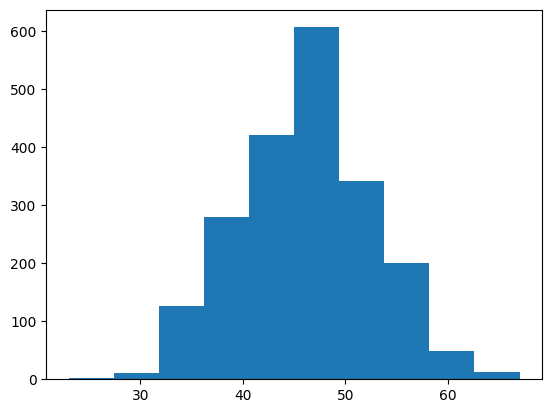

In [10]:
plt.hist(eval_stats['trade_count_paths'])

(array([  1.,  11., 120., 336., 520., 561., 327., 129.,  36.,   7.]),
 array([135.76626587, 167.11653137, 198.46679688, 229.81707764,
        261.1673584 , 292.51760864, 323.8678894 , 355.21813965,
        386.56842041, 417.91870117, 449.26895142]),
 <BarContainer object of 10 artists>)

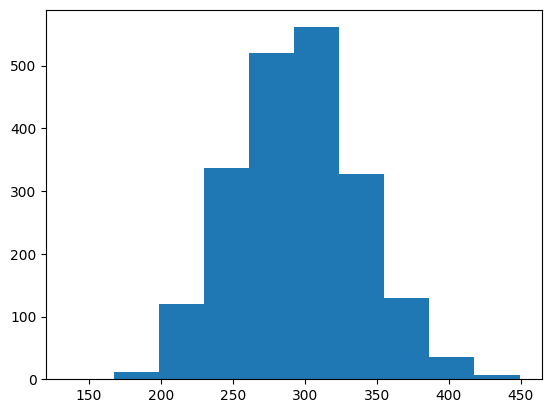

In [11]:
plt.hist(eval_stats['total_cost_paths'])

In [15]:
# ---------------------------------------------------------------------
# Assign trained model and environment
# ---------------------------------------------------------------------
agent = result["agent"]
env = result["env"]


# ---------------------------------------------------------------------
# Option B: load from checkpoint instead
# ---------------------------------------------------------------------
# loaded = load_ppo_sil("./PPO models/PPO_SIL_pfolio_mps_trunk.pt", device=DEVICE)
# agent = loaded["agent"]
# env = loaded["env"]


# ---------------------------------------------------------------------
# Asset names for legends
# ---------------------------------------------------------------------
asset_names = df["TKR"].astype(str).tolist()

# ---------------------------------------------------------------------
# Multi-path evaluation metrics, including Sharpe ratios
# ---------------------------------------------------------------------
eval_stats = evaluate_policy(
    agent,
    env,
    n_envs=2048,
    deterministic=False,
    batch_size=256,
)

print("Evaluation metrics:")
for k, v in eval_stats.items():
    if isinstance(v, np.ndarray):
        continue
    print(f"{k}: {v}")

print("\nSharpe metrics:")
print("sharpe_ratio:", eval_stats["sharpe_ratio"])
print("annualized_sharpe_ratio:", eval_stats["annualized_sharpe_ratio"])
print("discounted_sharpe_ratio:", eval_stats["discounted_sharpe_ratio"])
print("annualized_discounted_sharpe_ratio:", eval_stats["annualized_discounted_sharpe_ratio"])

Evaluation metrics:
initial_wealth_mean: 49930.10546875
terminal_wealth_mean: 54534.35546875
terminal_wealth_std: 1818.7315673828125
discounted_terminal_wealth_mean: 54534.35546875
discounted_terminal_wealth_std: 1818.7315673828125
terminal_profit_mean: 4604.251953125
terminal_profit_std: 1818.7315673828125
discounted_profit_mean: 4604.251953125
discounted_profit_std: 1818.7315673828125
terminal_return_mean: 0.0922139585018158
terminal_return_std: 0.036425553262233734
discounted_return_mean: 0.0922139585018158
discounted_return_std: 0.036425553262233734
sharpe_ratio: 2.5315731683070353
annualized_sharpe_ratio: 2.5315731683070353
discounted_sharpe_ratio: 2.5315731683070353
annualized_discounted_sharpe_ratio: 2.5315731683070353
trade_count_mean: 45.96875
trade_count_std: 6.560788631439209
total_cost_mean: 294.55133056640625
total_cost_std: 43.79665756225586
mean_abs_trade: 1.4038423299789429
final_cash_mean: 531.0328369140625

Sharpe metrics:
sharpe_ratio: 2.5315731683070353
annualized_s

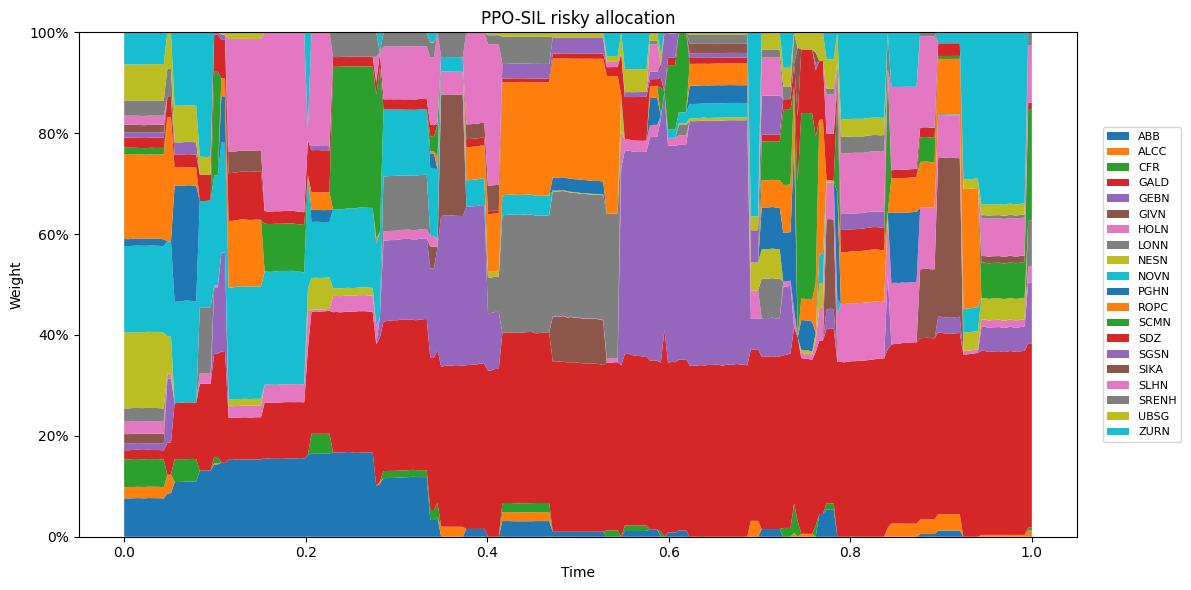

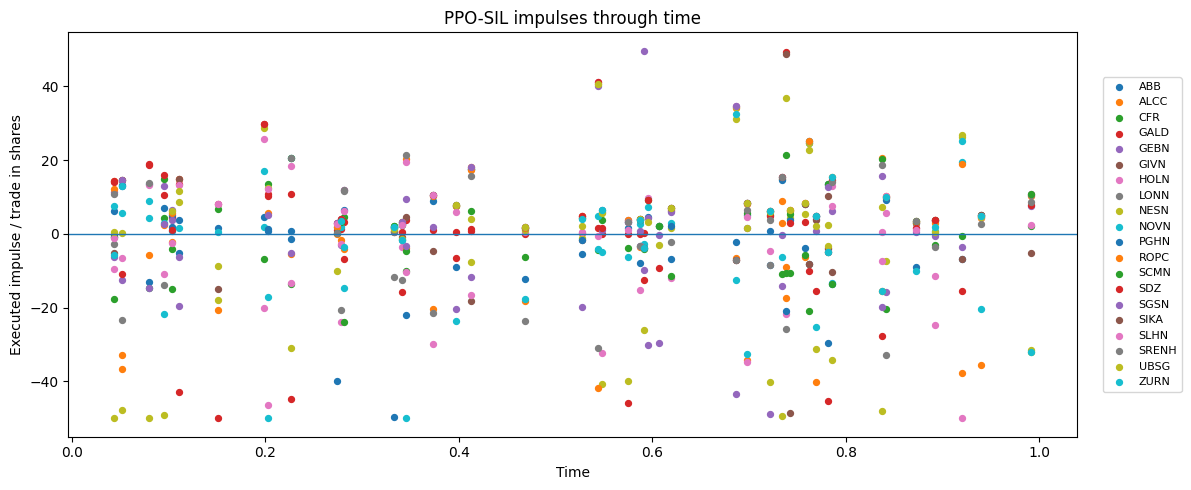

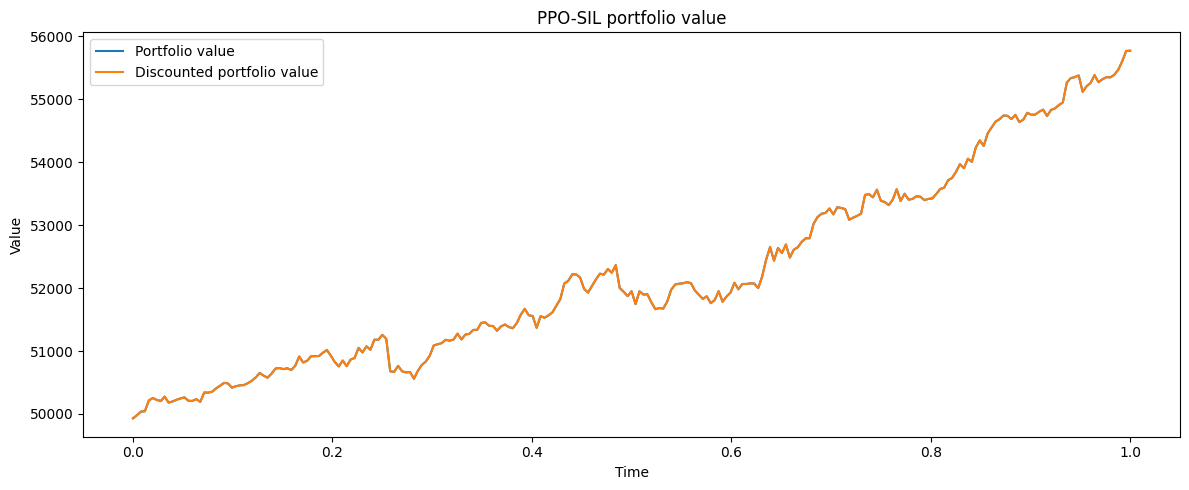


Single-path metrics:
initial_wealth: 49930.1015625
terminal_wealth: 55771.05859375
terminal_profit: 5840.95703125
terminal_return: 0.11698267875418966
discounted_terminal_wealth: 55771.05859375
discounted_profit: 5840.95703125
discounted_return: 0.11698267875418966
sharpe_ratio: 0.2280597200551714
annualized_sharpe_ratio: 3.6203358200219595
discounted_sharpe_ratio: 0.2280597200551714
annualized_discounted_sharpe_ratio: 3.6203358200219595
max_drawdown: -0.013577847688377553
discounted_max_drawdown: -0.013577847688377553
trade_count: 47.0
total_cost: 302.84455585479736
mean_abs_trade: 1.3436015466324371
mean_intervention_probability: 0.3040985570895293


,iter,policy_loss,value_loss,entropy,decision_entropy,impulse_entropy,kl,kl_decision,kl_impulse,sil_policy_loss,...,eval_discounted_profit_mean,eval_terminal_return_mean,eval_discounted_return_mean,eval_sharpe_ratio,eval_annualized_sharpe_ratio,eval_discounted_sharpe_ratio,eval_annualized_discounted_sharpe_ratio,eval_trade_count_mean,eval_total_cost_mean,eval_mean_abs_trade
95,96,0.005644,0.874645,17.338745,0.636973,48.378773,0.017994,0.003313,0.043163,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,97,0.002567,0.722229,16.470853,0.624499,48.378772,0.015836,0.003341,0.039572,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,98,0.002728,0.647400,15.146145,0.606180,48.378771,0.016979,0.003350,0.047689,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,99,0.002981,0.797490,15.742491,0.615475,48.378771,0.016361,0.003527,0.044045,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99,100,0.004862,0.905013,16.802608,0.631730,48.378772,0.017535,0.001130,0.051897,18.015612,...,4580.664062,0.091742,0.091742,2.442823,2.442823,2.442823,2.442823,45.970215,294.610474,1.402859


In [16]:
# ---------------------------------------------------------------------
# One-path evaluation and requested visualisations
# ---------------------------------------------------------------------
single_eval = evaluate_and_plot_single_path(
    agent,
    env,
    deterministic=False,
    asset_names=asset_names,
    include_cash_in_allocation=False,
    save_dir=None,
    show=True,
)

single_trace = single_eval["trace"]
single_metrics = single_eval["metrics"]

print("\nSingle-path metrics:")
for k, v in single_metrics.items():
    print(f"{k}: {v}")


# ---------------------------------------------------------------------
# Optional: inspect training history
# ---------------------------------------------------------------------
df_history = pd.DataFrame(result["history"])
display(df_history.tail())